# ProyectoG9 - Proceso ETL, Modelo Estrella y Tabla de Hechos

## Inteligencia de Negocios - Componente Práctico Semana 3

### Grupo 9

**Integrantes:**

- Guevara Paz y Miño Juan Diego
- Moreno Jeremy
- Solis Paulo


## 1. Introducción del proyecto

El presente notebook corresponde al desarrollo del proyecto práctico de la Semana 3, enfocado en la construcción de un modelo estrella a partir de datos previamente limpiados y transformados en el proceso ETL.

El proyecto trabaja con información relacionada con **ciberseguridad global e indicadores digitales por país**. Para ello, se utilizan tres fuentes principales:

1. **Global Cybersecurity Threats 2015-2024:** contiene información sobre incidentes globales de ciberseguridad, incluyendo país, año, tipo de ataque, industria afectada, pérdida financiera, usuarios afectados, fuente del ataque, vulnerabilidad, mecanismo de defensa y tiempo de resolución.
2. **Cyber Security Index:** contiene indicadores de ciberseguridad por país, como CEI, GCI, NCSI y DDL.
3. **Internet Users by Country:** contiene información sobre usuarios de internet, población y porcentaje de penetración de internet por país.

El objetivo de esta etapa es preparar los datos para una estructura analítica tipo Data Warehouse mediante:

- carga de DataFrames transformados,
- creación del modelo estrella,
- creación de dimensiones,
- creación de una tabla de hechos.

Este modelo permitirá analizar los incidentes de ciberseguridad desde diferentes perspectivas, como país, año, tipo de ataque, industria afectada y nivel de impacto.


## Instalación de dependencias necesarias

Antes de importar librerías, se verifica que el entorno tenga instalados los paquetes necesarios para ejecutar el notebook completo.

Esta celda ayuda a evitar errores como `ModuleNotFoundError`, especialmente con librerías como `matplotlib`, que se utiliza para las visualizaciones.

> Nota: esta celda debe ejecutarse una vez al inicio del notebook. Si las librerías ya existen en el entorno, no se reinstalan.


In [ ]:
import sys
import subprocess
import importlib.util

paquetes = [
    {"pip": "pandas", "modulo": "pandas"},
    {"pip": "matplotlib", "modulo": "matplotlib"},
    {"pip": "python-dotenv", "modulo": "dotenv"},
    {"pip": "sqlalchemy", "modulo": "sqlalchemy"},
    {"pip": "psycopg2-binary", "modulo": "psycopg2"},
    {"pip": "boto3", "modulo": "boto3"},
    {"pip": "redshift-connector", "modulo": "redshift_connector"}
]

for paquete in paquetes:
    nombre_pip = paquete["pip"]
    nombre_modulo = paquete["modulo"]

    if importlib.util.find_spec(nombre_modulo) is None:
        print(f"Instalando {nombre_pip}...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            nombre_pip
        ])
    else:
        print(f"{nombre_pip} ya está instalado.")

print("Validación de librerías finalizada correctamente.")

## 2. Importación de librerías

En esta sección se importan las librerías necesarias para cargar, limpiar, transformar y estructurar los datos.

Se utiliza principalmente:

- `pandas` para manipulación de DataFrames.
- `pathlib` para el manejo ordenado de rutas.
- `re` y `unicodedata` para normalización de textos.
- `IPython.display` para presentar tablas dentro del notebook.


In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display
import re
import unicodedata

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3. Carga de DataFrames transformados

En esta sección se cargan las fuentes originales del proyecto y se aplican nuevamente las transformaciones trabajadas en la Semana 2.

Esto permite obtener DataFrames limpios y preparados para construir el modelo estrella sin modificar los archivos originales.

Los DataFrames principales generados en esta sección son:

- `df_threats_transformed`
- `df_cyber_security_transformed`
- `df_internet_users_transformed`
- `df_threats_enriched`


In [2]:
# Configuración de rutas
DATA_DIR = Path("data")

ruta_threats = DATA_DIR / "Global_Cybersecurity_Threats_2015-2024.csv"
ruta_cyber_security = DATA_DIR / "Cyber_security.csv"
ruta_internet_users = DATA_DIR / "internet_users_by_country_cleaned.csv"

rutas_requeridas = [ruta_threats, ruta_cyber_security, ruta_internet_users]
archivos_faltantes = [str(ruta) for ruta in rutas_requeridas if not ruta.exists()]

if archivos_faltantes:
    raise FileNotFoundError(
        "No se encontraron los siguientes archivos requeridos: "
        + ", ".join(archivos_faltantes)
    )

# Carga de fuentes originales
df_threats = pd.read_csv(ruta_threats)
df_cyber_security = pd.read_csv(ruta_cyber_security)
df_internet_users = pd.read_csv(ruta_internet_users)

datasets = {
    "Global Cybersecurity Threats": df_threats,
    "Cyber Security Index": df_cyber_security,
    "Internet Users by Country": df_internet_users
}

resumen_carga = pd.DataFrame([
    {
        "fuente": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "valores_nulos": int(df.isnull().sum().sum()),
        "registros_duplicados": int(df.duplicated().sum())
    }
    for nombre, df in datasets.items()
])

resumen_carga

,fuente,filas,columnas,valores_nulos,registros_duplicados
0,Global Cybersecurity Threats,3000,10,0,0
1,Cyber Security Index,192,6,151,0
2,Internet Users by Country,215,7,0,0


### 3.1 Funciones de limpieza y normalización

Estas funciones permiten normalizar columnas, limpiar textos, homologar nombres de países y convertir columnas numéricas.


In [3]:
COUNTRY_MAPPING = {
    "USA": "United States",
    "U.S.A.": "United States",
    "US": "United States",
    "UK": "United Kingdom",
    "U.K.": "United Kingdom"
}


def normalizar_nombre_columna(columna):
    columna = columna.strip().lower()
    columna = columna.replace("$", "")
    columna = re.sub(r"[()/%]+", " ", columna)
    columna = re.sub(r"[^a-z0-9]+", "_", columna)
    columna = re.sub(r"_+", "_", columna)
    columna = columna.strip("_")
    return columna


def normalizar_texto(valor):
    if pd.isna(valor):
        return pd.NA

    valor = str(valor).strip()
    valor = re.sub(r"\s+", " ", valor)

    if valor == "":
        return pd.NA

    return valor


def homologar_pais(valor):
    valor = normalizar_texto(valor)

    if pd.isna(valor):
        return pd.NA

    return COUNTRY_MAPPING.get(valor, valor)


def limpiar_columnas_texto(df):
    df_limpio = df.copy()
    columnas_texto = df_limpio.select_dtypes(include=["object", "string"]).columns

    for columna in columnas_texto:
        df_limpio[columna] = df_limpio[columna].apply(normalizar_texto)

    return df_limpio


def convertir_columnas_numericas(df, columnas):
    df_limpio = df.copy()

    for columna in columnas:
        if columna in df_limpio.columns:
            df_limpio[columna] = pd.to_numeric(df_limpio[columna], errors="coerce")

    return df_limpio


print("Funciones de limpieza creadas correctamente.")

Funciones de limpieza creadas correctamente.


### 3.2 Limpieza de fuentes

Se aplican funciones específicas para cada fuente de datos.  
El objetivo es obtener DataFrames con columnas normalizadas, tipos de datos correctos y campos preparados para la relación entre fuentes.


In [4]:
def limpiar_threats(df):
    df_limpio = df.copy()
    df_limpio.columns = [normalizar_nombre_columna(col) for col in df_limpio.columns]
    df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
    df_limpio = limpiar_columnas_texto(df_limpio)
    df_limpio["country"] = df_limpio["country"].apply(homologar_pais)

    columnas_numericas = [
        "year",
        "financial_loss_in_million",
        "number_of_affected_users",
        "incident_resolution_time_in_hours"
    ]

    df_limpio = convertir_columnas_numericas(df_limpio, columnas_numericas)
    df_limpio["year"] = df_limpio["year"].astype("Int64")

    return df_limpio


def limpiar_cyber_security(df):
    df_limpio = df.copy()
    df_limpio.columns = [normalizar_nombre_columna(col) for col in df_limpio.columns]
    df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
    df_limpio = limpiar_columnas_texto(df_limpio)
    df_limpio["country"] = df_limpio["country"].apply(homologar_pais)

    df_limpio["region"] = df_limpio["region"].replace({
        "Asia-Pasific": "Asia-Pacific"
    })

    columnas_numericas = ["cei", "gci", "ncsi", "ddl"]
    df_limpio = convertir_columnas_numericas(df_limpio, columnas_numericas)

    df_limpio["has_missing_security_index"] = df_limpio[columnas_numericas].isnull().any(axis=1)

    return df_limpio


def limpiar_internet_users(df):
    df_limpio = df.copy()
    df_limpio.columns = [normalizar_nombre_columna(col) for col in df_limpio.columns]

    if "country_or_area" in df_limpio.columns:
        df_limpio = df_limpio.rename(columns={"country_or_area": "country"})

    df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
    df_limpio = limpiar_columnas_texto(df_limpio)
    df_limpio["country"] = df_limpio["country"].apply(homologar_pais)

    columnas_numericas = [
        "internet_users",
        "population_2021",
        "year",
        "percentage_internet_users"
    ]

    df_limpio = convertir_columnas_numericas(df_limpio, columnas_numericas)
    df_limpio["year"] = df_limpio["year"].astype("Int64")
    df_limpio["has_missing_digital_data"] = df_limpio[columnas_numericas].isnull().any(axis=1)

    return df_limpio


df_threats_clean = limpiar_threats(df_threats)
df_cyber_security_clean = limpiar_cyber_security(df_cyber_security)
df_internet_users_clean = limpiar_internet_users(df_internet_users)

print("Fuentes limpiadas correctamente.")

Fuentes limpiadas correctamente.


### 3.3 Selección de columnas relevantes

Se seleccionan las columnas necesarias para el análisis y para la construcción posterior del modelo estrella.


In [5]:
columnas_threats = [
    "country",
    "year",
    "attack_type",
    "target_industry",
    "financial_loss_in_million",
    "number_of_affected_users",
    "attack_source",
    "security_vulnerability_type",
    "defense_mechanism_used",
    "incident_resolution_time_in_hours"
]

columnas_cyber_security = [
    "country",
    "region",
    "cei",
    "gci",
    "ncsi",
    "ddl",
    "has_missing_security_index"
]

columnas_internet_users = [
    "country",
    "subregion",
    "region",
    "internet_users",
    "population_2021",
    "year",
    "percentage_internet_users",
    "has_missing_digital_data"
]

df_threats_selected = df_threats_clean[columnas_threats].copy()
df_cyber_security_selected = df_cyber_security_clean[columnas_cyber_security].copy()
df_internet_users_selected = df_internet_users_clean[columnas_internet_users].copy()

print("Columnas relevantes seleccionadas correctamente.")

Columnas relevantes seleccionadas correctamente.


### 3.4 Funciones auxiliares de transformación

Estas funciones permiten crear claves limpias y categorizar variables numéricas para facilitar el análisis posterior.


In [6]:
def crear_clave_texto(valor):
    if pd.isna(valor):
        return pd.NA

    valor = str(valor).strip().lower()
    valor = unicodedata.normalize("NFKD", valor).encode("ascii", "ignore").decode("utf-8")
    valor = re.sub(r"[^a-z0-9]+", "_", valor)
    valor = re.sub(r"_+", "_", valor)
    valor = valor.strip("_")

    return valor


def categorizar_perdida_financiera(valor):
    if pd.isna(valor):
        return "Sin dato"
    if valor < 25:
        return "Baja"
    if valor < 50:
        return "Media"
    if valor < 75:
        return "Alta"
    return "Crítica"


def categorizar_usuarios_afectados(valor):
    if pd.isna(valor):
        return "Sin dato"
    if valor < 250_000:
        return "Bajo impacto"
    if valor < 500_000:
        return "Impacto medio"
    if valor < 750_000:
        return "Impacto alto"
    return "Impacto crítico"


def categorizar_tiempo_resolucion(valor):
    if pd.isna(valor):
        return "Sin dato"
    if valor <= 24:
        return "Resolución rápida"
    if valor <= 48:
        return "Resolución media"
    return "Resolución lenta"


def categorizar_indicador_0_100(valor):
    if pd.isna(valor):
        return "Sin dato"
    if valor < 40:
        return "Bajo"
    if valor < 70:
        return "Medio"
    if valor < 85:
        return "Alto"
    return "Muy alto"


def categorizar_penetracion_internet(valor):
    if pd.isna(valor):
        return "Sin dato"
    if valor < 40:
        return "Baja"
    if valor < 70:
        return "Media"
    if valor < 90:
        return "Alta"
    return "Muy alta"


print("Funciones auxiliares creadas correctamente.")

Funciones auxiliares creadas correctamente.


### 3.5 Generación de DataFrames transformados

Se crean los DataFrames transformados que servirán como base para el modelo estrella.


In [7]:
# Transformación del dataset de amenazas
df_threats_transformed = df_threats_selected.copy()

df_threats_transformed["country_key"] = df_threats_transformed["country"].apply(crear_clave_texto)

df_threats_transformed["country_year_key"] = (
    df_threats_transformed["country_key"]
    + "_"
    + df_threats_transformed["year"].astype(str)
)

df_threats_transformed["financial_loss_usd"] = (
    df_threats_transformed["financial_loss_in_million"] * 1_000_000
)

df_threats_transformed["incident_year_start_date"] = pd.to_datetime(
    df_threats_transformed["year"].astype(str) + "-01-01",
    errors="coerce"
)

df_threats_transformed["financial_loss_category"] = df_threats_transformed[
    "financial_loss_in_million"
].apply(categorizar_perdida_financiera)

df_threats_transformed["affected_users_category"] = df_threats_transformed[
    "number_of_affected_users"
].apply(categorizar_usuarios_afectados)

df_threats_transformed["resolution_time_category"] = df_threats_transformed[
    "incident_resolution_time_in_hours"
].apply(categorizar_tiempo_resolucion)


# Transformación del dataset de índices de ciberseguridad
df_cyber_security_transformed = df_cyber_security_selected.copy()

df_cyber_security_transformed["country_key"] = df_cyber_security_transformed[
    "country"
].apply(crear_clave_texto)

df_cyber_security_transformed["cei_percentage"] = df_cyber_security_transformed["cei"] * 100

indicadores_ciberseguridad = ["cei", "gci", "ncsi", "ddl"]

df_cyber_security_transformed["available_security_indicators"] = df_cyber_security_transformed[
    indicadores_ciberseguridad
].notnull().sum(axis=1)

df_cyber_security_transformed["gci_level"] = df_cyber_security_transformed[
    "gci"
].apply(categorizar_indicador_0_100)

df_cyber_security_transformed["ncsi_level"] = df_cyber_security_transformed[
    "ncsi"
].apply(categorizar_indicador_0_100)

df_cyber_security_transformed["ddl_level"] = df_cyber_security_transformed[
    "ddl"
].apply(categorizar_indicador_0_100)

df_cyber_security_transformed["has_complete_security_index"] = ~df_cyber_security_transformed[
    "has_missing_security_index"
]


# Transformación del dataset de usuarios de internet
df_internet_users_transformed = df_internet_users_selected.copy()

df_internet_users_transformed["country_key"] = df_internet_users_transformed[
    "country"
].apply(crear_clave_texto)

df_internet_users_transformed["country_year_key"] = (
    df_internet_users_transformed["country_key"]
    + "_"
    + df_internet_users_transformed["year"].astype(str)
)

df_internet_users_transformed["internet_users_millions"] = (
    df_internet_users_transformed["internet_users"] / 1_000_000
).round(2)

df_internet_users_transformed["population_millions"] = (
    df_internet_users_transformed["population_2021"] / 1_000_000
).round(2)

df_internet_users_transformed["internet_users_ratio"] = (
    df_internet_users_transformed["percentage_internet_users"] / 100
).round(4)

df_internet_users_transformed["internet_year_start_date"] = pd.to_datetime(
    df_internet_users_transformed["year"].astype(str) + "-01-01",
    errors="coerce"
)

df_internet_users_transformed["internet_penetration_level"] = df_internet_users_transformed[
    "percentage_internet_users"
].apply(categorizar_penetracion_internet)

print("DataFrames transformados generados correctamente.")

DataFrames transformados generados correctamente.


### 3.6 Creación de DataFrame enriquecido

Se crea un DataFrame enriquecido a partir de los incidentes de ciberseguridad, agregando indicadores de ciberseguridad y datos de usuarios de internet por país.


In [8]:
cyber_security_context = df_cyber_security_transformed[[
    "country",
    "region",
    "cei",
    "gci",
    "ncsi",
    "ddl",
    "cei_percentage",
    "gci_level",
    "ncsi_level",
    "ddl_level",
    "available_security_indicators",
    "has_complete_security_index"
]].rename(columns={
    "region": "security_region"
})

internet_users_context = df_internet_users_transformed[[
    "country",
    "subregion",
    "region",
    "year",
    "internet_users",
    "population_2021",
    "percentage_internet_users",
    "internet_users_millions",
    "population_millions",
    "internet_users_ratio",
    "internet_penetration_level"
]].rename(columns={
    "region": "internet_region",
    "year": "internet_data_year"
})

df_threats_enriched = (
    df_threats_transformed
    .merge(cyber_security_context, on="country", how="left")
    .merge(internet_users_context, on="country", how="left")
)

print("DataFrame enriquecido generado correctamente.")
print("Filas en df_threats_transformed:", df_threats_transformed.shape[0])
print("Filas en df_threats_enriched:", df_threats_enriched.shape[0])

DataFrame enriquecido generado correctamente.
Filas en df_threats_transformed: 3000
Filas en df_threats_enriched: 3000


In [9]:
dataframes_transformados = {
    "df_threats_transformed": df_threats_transformed,
    "df_cyber_security_transformed": df_cyber_security_transformed,
    "df_internet_users_transformed": df_internet_users_transformed,
    "df_threats_enriched": df_threats_enriched
}

resumen_transformados = pd.DataFrame([
    {
        "dataframe": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "valores_nulos": int(df.isnull().sum().sum()),
        "registros_duplicados": int(df.duplicated().sum())
    }
    for nombre, df in dataframes_transformados.items()
])

resumen_transformados

,dataframe,filas,columnas,valores_nulos,registros_duplicados
0,df_threats_transformed,3000,17,0,0
1,df_cyber_security_transformed,192,14,235,0
2,df_internet_users_transformed,215,15,0,0
3,df_threats_enriched,3000,38,0,0


## 4. Creación del modelo estrella

En esta sección se define el modelo estrella que será utilizado para estructurar los datos transformados en un formato analítico.

Un modelo estrella se compone de:

- **Tabla de hechos:** contiene los eventos principales del análisis y sus métricas.
- **Tablas de dimensiones:** contienen atributos descriptivos que permiten analizar los hechos desde diferentes perspectivas.

Para este proyecto, la tabla principal de hechos será `fact_cybersecurity_incidents`, ya que cada registro representa un incidente de ciberseguridad.

La granularidad de la tabla de hechos será:

> **Un registro por cada incidente de ciberseguridad reportado en el dataset Global Cybersecurity Threats.**


In [10]:
modelo_estrella = pd.DataFrame([
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_country", "descripcion": "Países y atributos geográficos o contextuales."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_year", "descripcion": "Años disponibles para el análisis temporal."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_attack_type", "descripcion": "Tipos de ataques de ciberseguridad."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_target_industry", "descripcion": "Industrias afectadas por incidentes."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_attack_source", "descripcion": "Fuentes u orígenes de los ataques."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_vulnerability", "descripcion": "Tipos de vulnerabilidades asociadas a incidentes."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_defense_mechanism", "descripcion": "Mecanismos de defensa utilizados."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_financial_loss_category", "descripcion": "Categorías de pérdida financiera."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_affected_users_category", "descripcion": "Categorías de impacto según usuarios afectados."},
    {"tipo_tabla": "Dimensión", "nombre_tabla": "dim_resolution_time_category", "descripcion": "Categorías de tiempo de resolución."},
    {"tipo_tabla": "Hechos", "nombre_tabla": "fact_cybersecurity_incidents", "descripcion": "Incidentes de ciberseguridad y métricas principales."}
])

modelo_estrella

,tipo_tabla,nombre_tabla,descripcion
0,Dimensión,dim_country,Países y atributos geográficos o contextuales.
1,Dimensión,dim_year,Años disponibles para el análisis temporal.
2,Dimensión,dim_attack_type,Tipos de ataques de ciberseguridad.
3,Dimensión,dim_target_industry,Industrias afectadas por incidentes.
4,Dimensión,dim_attack_source,Fuentes u orígenes de los ataques.
5,Dimensión,dim_vulnerability,Tipos de vulnerabilidades asociadas a incidentes.
6,Dimensión,dim_defense_mechanism,Mecanismos de defensa utilizados.
7,Dimensión,dim_financial_loss_category,Categorías de pérdida financiera.
8,Dimensión,dim_affected_users_category,Categorías de impacto según usuarios afectados.
9,Dimensión,dim_resolution_time_category,Categorías de tiempo de resolución.


### 4.1 Estructura propuesta del modelo

Representación conceptual:

```text
                           dim_country
                               |
dim_attack_type -------- fact_cybersecurity_incidents -------- dim_year
                               |
dim_target_industry             |
                               |
dim_attack_source               |
                               |
dim_vulnerability               |
                               |
dim_defense_mechanism           |
                               |
dim_financial_loss_category     |
                               |
dim_affected_users_category     |
                               |
dim_resolution_time_category
```


## 5. Creación de dimensiones

En esta sección se crean las tablas de dimensiones del modelo estrella.

Cada dimensión contiene valores únicos de una categoría analítica y un identificador numérico secuencial.  
Estos identificadores serán usados posteriormente como claves foráneas en la tabla de hechos.


In [11]:
def crear_dimension(df, columnas_dimension, nombre_id, ordenar_por=None):
    dimension = df[columnas_dimension].drop_duplicates().copy()

    if ordenar_por is not None and ordenar_por in dimension.columns:
        dimension = dimension.sort_values(by=ordenar_por)
    else:
        dimension = dimension.sort_values(by=columnas_dimension)

    dimension = dimension.reset_index(drop=True)
    dimension.insert(0, nombre_id, range(1, len(dimension) + 1))

    return dimension


print("Función crear_dimension creada correctamente.")

Función crear_dimension creada correctamente.


### 5.1 Dimensión de países

La dimensión `dim_country` consolida los países presentes en las fuentes transformadas e incluye atributos de contexto geográfico y digital.


In [12]:
paises_unicos = sorted(
    set(df_threats_transformed["country"].dropna())
    .union(set(df_cyber_security_transformed["country"].dropna()))
    .union(set(df_internet_users_transformed["country"].dropna()))
)

dim_country = pd.DataFrame({
    "country": paises_unicos
})

dim_country["country_key"] = dim_country["country"].apply(crear_clave_texto)

country_security_context = (
    df_cyber_security_transformed[[
        "country",
        "region",
        "gci_level",
        "ncsi_level",
        "ddl_level",
        "has_complete_security_index"
    ]]
    .drop_duplicates(subset=["country"])
    .rename(columns={"region": "security_region"})
)

country_internet_context = (
    df_internet_users_transformed[[
        "country",
        "subregion",
        "region",
        "internet_penetration_level"
    ]]
    .drop_duplicates(subset=["country"])
    .rename(columns={"region": "internet_region"})
)

dim_country = (
    dim_country
    .merge(country_security_context, on="country", how="left")
    .merge(country_internet_context, on="country", how="left")
)

dim_country.insert(0, "country_id", range(1, len(dim_country) + 1))

dim_country.head()

,country_id,country,country_key,security_region,gci_level,ncsi_level,ddl_level,has_complete_security_index,subregion,internet_region,internet_penetration_level
0,1,Afghanistan,afghanistan,Asia-Pacific,Bajo,Bajo,Bajo,True,Southern Asia,Asia,Baja
1,2,Albania,albania,Europe,Medio,Medio,Medio,True,Southern Europe,Europe,Alta
2,3,Algeria,algeria,Africa,Bajo,Bajo,Medio,True,Northern Africa,Africa,Media
3,4,Andorra,andorra,Europe,Bajo,Sin dato,Sin dato,False,Southern Europe,Europe,Muy alta
4,5,Angola,angola,Africa,Bajo,Bajo,Bajo,False,Middle Africa,Africa,Baja


### 5.2 Dimensión de tiempo

La dimensión `dim_year` permite analizar los incidentes y datos digitales por año.


In [13]:
years_unicos = sorted(
    set(df_threats_transformed["year"].dropna().astype(int))
    .union(set(df_internet_users_transformed["year"].dropna().astype(int)))
)

dim_year = pd.DataFrame({
    "year": years_unicos
})

dim_year["year_start_date"] = pd.to_datetime(
    dim_year["year"].astype(str) + "-01-01",
    errors="coerce"
)

dim_year["year_end_date"] = pd.to_datetime(
    dim_year["year"].astype(str) + "-12-31",
    errors="coerce"
)

dim_year.insert(0, "year_id", range(1, len(dim_year) + 1))

dim_year

,year_id,year,year_start_date,year_end_date
0,1,2015,2015-01-01,2015-12-31
1,2,2016,2016-01-01,2016-12-31
2,3,2017,2017-01-01,2017-12-31
3,4,2018,2018-01-01,2018-12-31
4,5,2019,2019-01-01,2019-12-31
5,6,2020,2020-01-01,2020-12-31
6,7,2021,2021-01-01,2021-12-31
7,8,2022,2022-01-01,2022-12-31
8,9,2023,2023-01-01,2023-12-31
9,10,2024,2024-01-01,2024-12-31


### 5.3 Dimensiones descriptivas y categorías analíticas

Se crean las dimensiones relacionadas con los atributos principales de los incidentes y las categorías derivadas en la transformación.


In [14]:
dim_attack_type = crear_dimension(
    df_threats_transformed,
    ["attack_type"],
    "attack_type_id"
)

dim_target_industry = crear_dimension(
    df_threats_transformed,
    ["target_industry"],
    "target_industry_id"
)

dim_attack_source = crear_dimension(
    df_threats_transformed,
    ["attack_source"],
    "attack_source_id"
)

dim_vulnerability = crear_dimension(
    df_threats_transformed,
    ["security_vulnerability_type"],
    "vulnerability_id"
)

dim_defense_mechanism = crear_dimension(
    df_threats_transformed,
    ["defense_mechanism_used"],
    "defense_mechanism_id"
)

dim_financial_loss_category = crear_dimension(
    df_threats_transformed,
    ["financial_loss_category"],
    "financial_loss_category_id"
)

dim_affected_users_category = crear_dimension(
    df_threats_transformed,
    ["affected_users_category"],
    "affected_users_category_id"
)

dim_resolution_time_category = crear_dimension(
    df_threats_transformed,
    ["resolution_time_category"],
    "resolution_time_category_id"
)

print("Dimensiones creadas correctamente.")

Dimensiones creadas correctamente.


### 5.4 Resumen de dimensiones creadas

Se valida la cantidad de filas, columnas, duplicados y valores nulos de cada dimensión.


In [15]:
dimensiones = {
    "dim_country": dim_country,
    "dim_year": dim_year,
    "dim_attack_type": dim_attack_type,
    "dim_target_industry": dim_target_industry,
    "dim_attack_source": dim_attack_source,
    "dim_vulnerability": dim_vulnerability,
    "dim_defense_mechanism": dim_defense_mechanism,
    "dim_financial_loss_category": dim_financial_loss_category,
    "dim_affected_users_category": dim_affected_users_category,
    "dim_resolution_time_category": dim_resolution_time_category
}

resumen_dimensiones = pd.DataFrame([
    {
        "dimension": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "duplicados": int(df.duplicated().sum()),
        "valores_nulos": int(df.isnull().sum().sum())
    }
    for nombre, df in dimensiones.items()
])

resumen_dimensiones

,dimension,filas,columnas,duplicados,valores_nulos
0,dim_country,222,11,0,171
1,dim_year,10,4,0,0
2,dim_attack_type,6,2,0,0
3,dim_target_industry,7,2,0,0
4,dim_attack_source,4,2,0,0
5,dim_vulnerability,4,2,0,0
6,dim_defense_mechanism,5,2,0,0
7,dim_financial_loss_category,4,2,0,0
8,dim_affected_users_category,4,2,0,0
9,dim_resolution_time_category,3,2,0,0


## 6. Creación de tabla de hechos

En esta sección se crea la tabla de hechos `fact_cybersecurity_incidents`.

La tabla de hechos contiene las claves que conectan con las dimensiones y las métricas principales del análisis.

La granularidad de esta tabla es:

> **Un registro por cada incidente de ciberseguridad.**

Las métricas principales son:

- pérdida financiera en millones,
- pérdida financiera en dólares,
- número de usuarios afectados,
- tiempo de resolución en horas,
- indicadores de ciberseguridad del país,
- usuarios de internet,
- población,
- porcentaje de usuarios de internet.


In [16]:
fact_cybersecurity_incidents = df_threats_enriched.copy()

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_country[["country_id", "country"]],
    on="country",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_year[["year_id", "year"]],
    on="year",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_attack_type,
    on="attack_type",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_target_industry,
    on="target_industry",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_attack_source,
    on="attack_source",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_vulnerability,
    on="security_vulnerability_type",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_defense_mechanism,
    on="defense_mechanism_used",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_financial_loss_category,
    on="financial_loss_category",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_affected_users_category,
    on="affected_users_category",
    how="left"
)

fact_cybersecurity_incidents = fact_cybersecurity_incidents.merge(
    dim_resolution_time_category,
    on="resolution_time_category",
    how="left"
)

fact_cybersecurity_incidents.insert(
    0,
    "incident_fact_id",
    range(1, len(fact_cybersecurity_incidents) + 1)
)

print("Tabla de hechos creada correctamente.")
print("Filas:", fact_cybersecurity_incidents.shape[0])
print("Columnas:", fact_cybersecurity_incidents.shape[1])

Tabla de hechos creada correctamente.
Filas: 3000
Columnas: 49


### 6.1 Selección de columnas finales de la tabla de hechos

Se seleccionan únicamente las claves y métricas que deben quedar en la tabla de hechos, evitando duplicar información descriptiva que ya se encuentra en las dimensiones.


In [17]:
columnas_fact = [
    "incident_fact_id",
    "country_id",
    "year_id",
    "attack_type_id",
    "target_industry_id",
    "attack_source_id",
    "vulnerability_id",
    "defense_mechanism_id",
    "financial_loss_category_id",
    "affected_users_category_id",
    "resolution_time_category_id",
    "financial_loss_in_million",
    "financial_loss_usd",
    "number_of_affected_users",
    "incident_resolution_time_in_hours",
    "cei",
    "gci",
    "ncsi",
    "ddl",
    "internet_users",
    "population_2021",
    "percentage_internet_users"
]

fact_cybersecurity_incidents = fact_cybersecurity_incidents[columnas_fact].copy()

fact_cybersecurity_incidents.head()

,incident_fact_id,country_id,year_id,attack_type_id,target_industry_id,attack_source_id,vulnerability_id,defense_mechanism_id,financial_loss_category_id,affected_users_category_id,resolution_time_category_id,financial_loss_in_million,financial_loss_usd,number_of_affected_users,incident_resolution_time_in_hours,cei,gci,ncsi,ddl,internet_users,population_2021,percentage_internet_users
0,1,42,5,4,2,1,2,5,3,3,1,80.53,80530000.0,773169,63,0.483,92.53,51.95,62.41,1102140000,1425893465,77.3
1,2,42,5,5,6,1,2,4,1,4,1,62.19,62190000.0,295961,71,0.483,92.53,51.95,62.41,1102140000,1425893465,77.3
2,3,92,3,3,5,1,3,5,4,2,3,38.65,38650000.0,605895,20,0.597,97.50,59.74,40.02,881250000,1407563842,62.6
3,4,211,10,5,7,3,1,1,4,2,3,41.44,41440000.0,659320,7,0.207,99.54,89.61,79.96,65001016,67281039,96.6
4,5,76,4,3,5,2,1,5,1,3,1,74.41,74410000.0,810682,68,0.241,97.41,90.91,80.01,77794405,83408554,93.3


### 6.2 Validación de la tabla de hechos

Se valida que la tabla de hechos conserve todos los incidentes del dataset principal y que las claves de relación con las dimensiones no contengan valores nulos.


In [18]:
columnas_clave_fact = [
    "country_id",
    "year_id",
    "attack_type_id",
    "target_industry_id",
    "attack_source_id",
    "vulnerability_id",
    "defense_mechanism_id",
    "financial_loss_category_id",
    "affected_users_category_id",
    "resolution_time_category_id"
]

validacion_fact = pd.DataFrame([
    {
        "validacion": "La tabla de hechos conserva todos los incidentes",
        "resultado": fact_cybersecurity_incidents.shape[0] == df_threats_transformed.shape[0],
        "detalle": f"{fact_cybersecurity_incidents.shape[0]} registros en hechos vs {df_threats_transformed.shape[0]} incidentes transformados"
    },
    {
        "validacion": "incident_fact_id es único",
        "resultado": fact_cybersecurity_incidents["incident_fact_id"].is_unique,
        "detalle": f"{fact_cybersecurity_incidents['incident_fact_id'].nunique()} identificadores únicos"
    },
    {
        "validacion": "No existen claves nulas en la tabla de hechos",
        "resultado": fact_cybersecurity_incidents[columnas_clave_fact].isnull().sum().sum() == 0,
        "detalle": f"{int(fact_cybersecurity_incidents[columnas_clave_fact].isnull().sum().sum())} claves nulas encontradas"
    },
    {
        "validacion": "No existen duplicados completos en la tabla de hechos",
        "resultado": fact_cybersecurity_incidents.duplicated().sum() == 0,
        "detalle": f"{int(fact_cybersecurity_incidents.duplicated().sum())} duplicados completos"
    }
])

validacion_fact

,validacion,resultado,detalle
0,La tabla de hechos conserva todos los incidentes,True,3000 registros en hechos vs 3000 incidentes tr...
1,incident_fact_id es único,True,3000 identificadores únicos
2,No existen claves nulas en la tabla de hechos,True,0 claves nulas encontradas
3,No existen duplicados completos en la tabla de...,True,0 duplicados completos


### 6.3 Resumen final del modelo estrella

Se consolida un resumen con todas las dimensiones y la tabla de hechos creada.


In [19]:
tablas_modelo_estrella = {
    **dimensiones,
    "fact_cybersecurity_incidents": fact_cybersecurity_incidents
}

resumen_modelo_estrella = pd.DataFrame([
    {
        "tabla": nombre,
        "tipo": "Hechos" if nombre.startswith("fact_") else "Dimensión",
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "duplicados": int(df.duplicated().sum()),
        "valores_nulos": int(df.isnull().sum().sum())
    }
    for nombre, df in tablas_modelo_estrella.items()
])

resumen_modelo_estrella

,tabla,tipo,filas,columnas,duplicados,valores_nulos
0,dim_country,Dimensión,222,11,0,171
1,dim_year,Dimensión,10,4,0,0
2,dim_attack_type,Dimensión,6,2,0,0
3,dim_target_industry,Dimensión,7,2,0,0
4,dim_attack_source,Dimensión,4,2,0,0
5,dim_vulnerability,Dimensión,4,2,0,0
6,dim_defense_mechanism,Dimensión,5,2,0,0
7,dim_financial_loss_category,Dimensión,4,2,0,0
8,dim_affected_users_category,Dimensión,4,2,0,0
9,dim_resolution_time_category,Dimensión,3,2,0,0


## 7. Validación del modelo estrella

En esta sección se valida que el modelo estrella haya sido construido correctamente.

La validación se enfoca en revisar:

- unicidad de los identificadores en cada dimensión,
- existencia de valores nulos en claves primarias,
- duplicados en dimensiones y tabla de hechos,
- conservación de la cantidad de incidentes,
- integridad referencial entre la tabla de hechos y las dimensiones.

Estas validaciones permiten confirmar que el modelo está preparado para ser exportado y cargado posteriormente en un destino analítico como Amazon Redshift.


### 7.1 Validación de dimensiones

Primero se revisa que cada dimensión tenga un identificador único y que no existan claves primarias nulas.


In [21]:
claves_dimensiones = {
    "dim_country": "country_id",
    "dim_year": "year_id",
    "dim_attack_type": "attack_type_id",
    "dim_target_industry": "target_industry_id",
    "dim_attack_source": "attack_source_id",
    "dim_vulnerability": "vulnerability_id",
    "dim_defense_mechanism": "defense_mechanism_id",
    "dim_financial_loss_category": "financial_loss_category_id",
    "dim_affected_users_category": "affected_users_category_id",
    "dim_resolution_time_category": "resolution_time_category_id"
}

validacion_dimensiones = []

for nombre_dimension, columna_id in claves_dimensiones.items():
    df_dimension = dimensiones[nombre_dimension]

    validacion_dimensiones.append({
        "dimension": nombre_dimension,
        "clave_primaria": columna_id,
        "filas": df_dimension.shape[0],
        "ids_unicos": df_dimension[columna_id].nunique(),
        "id_es_unico": df_dimension[columna_id].is_unique,
        "ids_nulos": int(df_dimension[columna_id].isnull().sum()),
        "duplicados_completos": int(df_dimension.duplicated().sum())
    })

df_validacion_dimensiones = pd.DataFrame(validacion_dimensiones)

df_validacion_dimensiones

,dimension,clave_primaria,filas,ids_unicos,id_es_unico,ids_nulos,duplicados_completos
0,dim_country,country_id,222,222,True,0,0
1,dim_year,year_id,10,10,True,0,0
2,dim_attack_type,attack_type_id,6,6,True,0,0
3,dim_target_industry,target_industry_id,7,7,True,0,0
4,dim_attack_source,attack_source_id,4,4,True,0,0
5,dim_vulnerability,vulnerability_id,4,4,True,0,0
6,dim_defense_mechanism,defense_mechanism_id,5,5,True,0,0
7,dim_financial_loss_category,financial_loss_category_id,4,4,True,0,0
8,dim_affected_users_category,affected_users_category_id,4,4,True,0,0
9,dim_resolution_time_category,resolution_time_category_id,3,3,True,0,0


### 7.2 Validación de tabla de hechos

Se revisa que la tabla de hechos conserve todos los incidentes originales, que su identificador sea único y que sus claves foráneas no presenten valores nulos.


In [22]:
columnas_clave_fact = [
    "country_id",
    "year_id",
    "attack_type_id",
    "target_industry_id",
    "attack_source_id",
    "vulnerability_id",
    "defense_mechanism_id",
    "financial_loss_category_id",
    "affected_users_category_id",
    "resolution_time_category_id"
]

df_validacion_hechos = pd.DataFrame([
    {
        "validacion": "La tabla de hechos conserva todos los incidentes",
        "resultado": fact_cybersecurity_incidents.shape[0] == df_threats_transformed.shape[0],
        "detalle": f"{fact_cybersecurity_incidents.shape[0]} registros en hechos vs {df_threats_transformed.shape[0]} incidentes transformados"
    },
    {
        "validacion": "incident_fact_id es único",
        "resultado": fact_cybersecurity_incidents["incident_fact_id"].is_unique,
        "detalle": f"{fact_cybersecurity_incidents['incident_fact_id'].nunique()} identificadores únicos"
    },
    {
        "validacion": "No existen claves foráneas nulas",
        "resultado": fact_cybersecurity_incidents[columnas_clave_fact].isnull().sum().sum() == 0,
        "detalle": f"{int(fact_cybersecurity_incidents[columnas_clave_fact].isnull().sum().sum())} claves nulas encontradas"
    },
    {
        "validacion": "No existen duplicados completos en hechos",
        "resultado": fact_cybersecurity_incidents.duplicated().sum() == 0,
        "detalle": f"{int(fact_cybersecurity_incidents.duplicated().sum())} duplicados completos"
    }
])

df_validacion_hechos

,validacion,resultado,detalle
0,La tabla de hechos conserva todos los incidentes,True,3000 registros en hechos vs 3000 incidentes tr...
1,incident_fact_id es único,True,3000 identificadores únicos
2,No existen claves foráneas nulas,True,0 claves nulas encontradas
3,No existen duplicados completos en hechos,True,0 duplicados completos


### 7.3 Validación de integridad referencial

La integridad referencial permite comprobar que todas las claves foráneas de la tabla de hechos existan en sus respectivas dimensiones.

Si una clave de la tabla de hechos no existe en la dimensión correspondiente, significaría que hay registros huérfanos o relaciones incompletas.


In [23]:
relaciones_fact_dim = {
    "country_id": dim_country["country_id"],
    "year_id": dim_year["year_id"],
    "attack_type_id": dim_attack_type["attack_type_id"],
    "target_industry_id": dim_target_industry["target_industry_id"],
    "attack_source_id": dim_attack_source["attack_source_id"],
    "vulnerability_id": dim_vulnerability["vulnerability_id"],
    "defense_mechanism_id": dim_defense_mechanism["defense_mechanism_id"],
    "financial_loss_category_id": dim_financial_loss_category["financial_loss_category_id"],
    "affected_users_category_id": dim_affected_users_category["affected_users_category_id"],
    "resolution_time_category_id": dim_resolution_time_category["resolution_time_category_id"]
}

validacion_integridad = []

for columna_fact, serie_dimension in relaciones_fact_dim.items():
    claves_fact = set(fact_cybersecurity_incidents[columna_fact].dropna().unique())
    claves_dimension = set(serie_dimension.dropna().unique())
    claves_faltantes = claves_fact - claves_dimension

    validacion_integridad.append({
        "clave_foranea": columna_fact,
        "claves_en_hechos": len(claves_fact),
        "claves_en_dimension": len(claves_dimension),
        "claves_faltantes_en_dimension": len(claves_faltantes),
        "integridad_correcta": len(claves_faltantes) == 0
    })

df_validacion_integridad = pd.DataFrame(validacion_integridad)

df_validacion_integridad

,clave_foranea,claves_en_hechos,claves_en_dimension,claves_faltantes_en_dimension,integridad_correcta
0,country_id,10,222,0,True
1,year_id,10,10,0,True
2,attack_type_id,6,6,0,True
3,target_industry_id,7,7,0,True
4,attack_source_id,4,4,0,True
5,vulnerability_id,4,4,0,True
6,defense_mechanism_id,5,5,0,True
7,financial_loss_category_id,4,4,0,True
8,affected_users_category_id,4,4,0,True
9,resolution_time_category_id,3,3,0,True


### 7.4 Resumen general de validación

Se consolida el resultado de las validaciones principales para determinar si el modelo estrella se encuentra listo para ser exportado.


In [24]:
modelo_valido = (
    df_validacion_dimensiones["id_es_unico"].all()
    and (df_validacion_dimensiones["ids_nulos"].sum() == 0)
    and (df_validacion_dimensiones["duplicados_completos"].sum() == 0)
    and df_validacion_hechos["resultado"].all()
    and df_validacion_integridad["integridad_correcta"].all()
)

resumen_validacion_modelo = pd.DataFrame([
    {
        "validacion_general": "Modelo estrella válido para exportación",
        "resultado": modelo_valido,
        "detalle": "El modelo cumple las validaciones principales." if modelo_valido else "Revisar validaciones con resultado falso."
    }
])

resumen_validacion_modelo

,validacion_general,resultado,detalle
0,Modelo estrella válido para exportación,True,El modelo cumple las validaciones principales.


## 8. Generación de archivos CSV finales

En esta sección se generan los archivos CSV finales del modelo estrella.

Se exportan todas las dimensiones y la tabla de hechos en una carpeta local llamada `output/modelo_estrella`.

Estos archivos serán utilizados posteriormente para la carga hacia Amazon S3 y Amazon Redshift.


In [25]:
# Carpeta de salida para archivos CSV finales
# En PyCharm se creará normalmente dentro del proyecto: output/modelo_estrella.
# Si el entorno no permite escribir en esa carpeta, se usa una ruta alternativa temporal.

OUTPUT_DIR = Path("output") / "modelo_estrella"

try:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
except PermissionError:
    OUTPUT_DIR = Path("/mnt/data") / "output" / "modelo_estrella"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta de salida creada o verificada:")
print(OUTPUT_DIR.resolve())

Carpeta de salida creada o verificada:
/mnt/data/output/modelo_estrella


### 8.1 Exportación de dimensiones y tabla de hechos

Cada tabla del modelo estrella se exporta como archivo `.csv`.

Se utiliza `index=False` para evitar que pandas agregue una columna adicional con el índice del DataFrame.


In [26]:
archivos_generados = []

for nombre_tabla, df_tabla in tablas_modelo_estrella.items():
    ruta_archivo = OUTPUT_DIR / f"{nombre_tabla}.csv"
    df_tabla.to_csv(ruta_archivo, index=False, encoding="utf-8")

    archivos_generados.append({
        "tabla": nombre_tabla,
        "archivo_csv": str(ruta_archivo),
        "filas": df_tabla.shape[0],
        "columnas": df_tabla.shape[1],
        "archivo_existe": ruta_archivo.exists()
    })

df_archivos_generados = pd.DataFrame(archivos_generados)

df_archivos_generados

,tabla,archivo_csv,filas,columnas,archivo_existe
0,dim_country,/mnt/data/output/modelo_estrella/dim_country.csv,222,11,True
1,dim_year,/mnt/data/output/modelo_estrella/dim_year.csv,10,4,True
2,dim_attack_type,/mnt/data/output/modelo_estrella/dim_attack_ty...,6,2,True
3,dim_target_industry,/mnt/data/output/modelo_estrella/dim_target_in...,7,2,True
4,dim_attack_source,/mnt/data/output/modelo_estrella/dim_attack_so...,4,2,True
5,dim_vulnerability,/mnt/data/output/modelo_estrella/dim_vulnerabi...,4,2,True
6,dim_defense_mechanism,/mnt/data/output/modelo_estrella/dim_defense_m...,5,2,True
7,dim_financial_loss_category,/mnt/data/output/modelo_estrella/dim_financial...,4,2,True
8,dim_affected_users_category,/mnt/data/output/modelo_estrella/dim_affected_...,4,2,True
9,dim_resolution_time_category,/mnt/data/output/modelo_estrella/dim_resolutio...,3,2,True


### 8.2 Validación de archivos generados

Se valida que todos los archivos CSV hayan sido creados correctamente en la carpeta de salida.


In [27]:
total_tablas_exportadas = len(tablas_modelo_estrella)
total_archivos_existentes = int(df_archivos_generados["archivo_existe"].sum())

validacion_archivos_csv = pd.DataFrame([
    {
        "validacion": "Todos los archivos CSV fueron generados",
        "resultado": total_tablas_exportadas == total_archivos_existentes,
        "detalle": f"{total_archivos_existentes} archivos generados de {total_tablas_exportadas} tablas"
    }
])

validacion_archivos_csv

,validacion,resultado,detalle
0,Todos los archivos CSV fueron generados,True,11 archivos generados de 11 tablas


## 9. Visualizaciones

En esta sección se crean tres visualizaciones diferentes para interpretar los datos del modelo estrella.

Las visualizaciones seleccionadas son:

1. **Pérdida financiera total por país.**
2. **Cantidad de incidentes por año.**
3. **Relación entre GCI y pérdida financiera total por país.**

Estas visualizaciones ayudan a comprender el impacto económico, la evolución temporal y la relación entre indicadores de ciberseguridad y pérdidas asociadas a incidentes.


In [28]:
import matplotlib.pyplot as plt

print("Librería de visualización importada correctamente.")

Librería de visualización importada correctamente.


### 9.1 Pérdida financiera total por país

Esta visualización permite identificar qué países concentran mayores pérdidas financieras asociadas a incidentes de ciberseguridad.


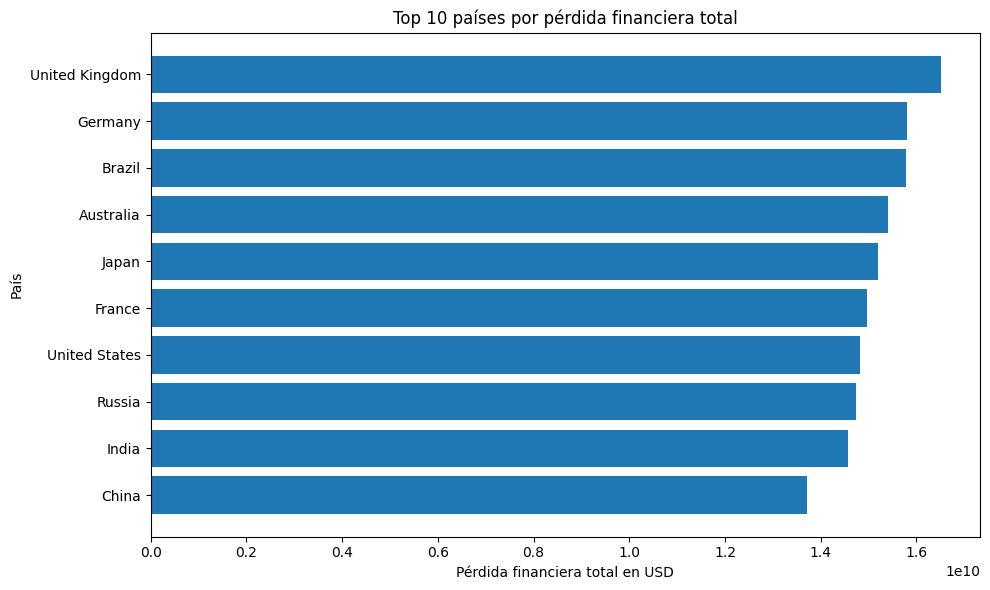

,country,financial_loss_usd
8,United Kingdom,1.650299e+10
4,Germany,1.579324e+10
1,Brazil,1.578262e+10
0,Australia,1.540300e+10
6,Japan,1.519734e+10
3,France,1.497228e+10
9,United States,1.481212e+10
7,Russia,1.473473e+10
5,India,1.456612e+10
2,China,1.371447e+10


In [29]:
df_viz_loss_country = (
    df_threats_enriched
    .groupby("country", as_index=False)["financial_loss_usd"]
    .sum()
    .sort_values(by="financial_loss_usd", ascending=False)
    .head(10)
    .sort_values(by="financial_loss_usd", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(df_viz_loss_country["country"], df_viz_loss_country["financial_loss_usd"])
plt.title("Top 10 países por pérdida financiera total")
plt.xlabel("Pérdida financiera total en USD")
plt.ylabel("País")
plt.tight_layout()
plt.show()

df_viz_loss_country.sort_values(by="financial_loss_usd", ascending=False)

### 9.2 Cantidad de incidentes por año

Esta visualización muestra la distribución temporal de los incidentes de ciberseguridad registrados en el dataset principal.


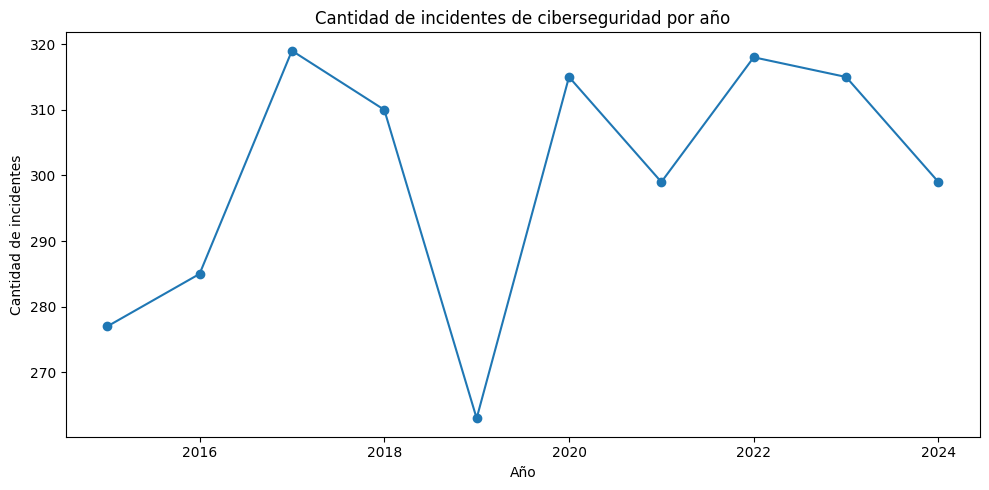

,year,total_incidents
0,2015,277
1,2016,285
2,2017,319
3,2018,310
4,2019,263
5,2020,315
6,2021,299
7,2022,318
8,2023,315
9,2024,299


In [30]:
df_viz_incidents_year = (
    df_threats_enriched
    .groupby("year", as_index=False)
    .agg(total_incidents=("country", "count"))
    .sort_values(by="year")
)

plt.figure(figsize=(10, 5))
plt.plot(df_viz_incidents_year["year"], df_viz_incidents_year["total_incidents"], marker="o")
plt.title("Cantidad de incidentes de ciberseguridad por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de incidentes")
plt.tight_layout()
plt.show()

df_viz_incidents_year

### 9.3 Relación entre GCI y pérdida financiera total por país

Esta visualización permite observar la relación entre el índice global de ciberseguridad promedio de cada país y la pérdida financiera total registrada en los incidentes.


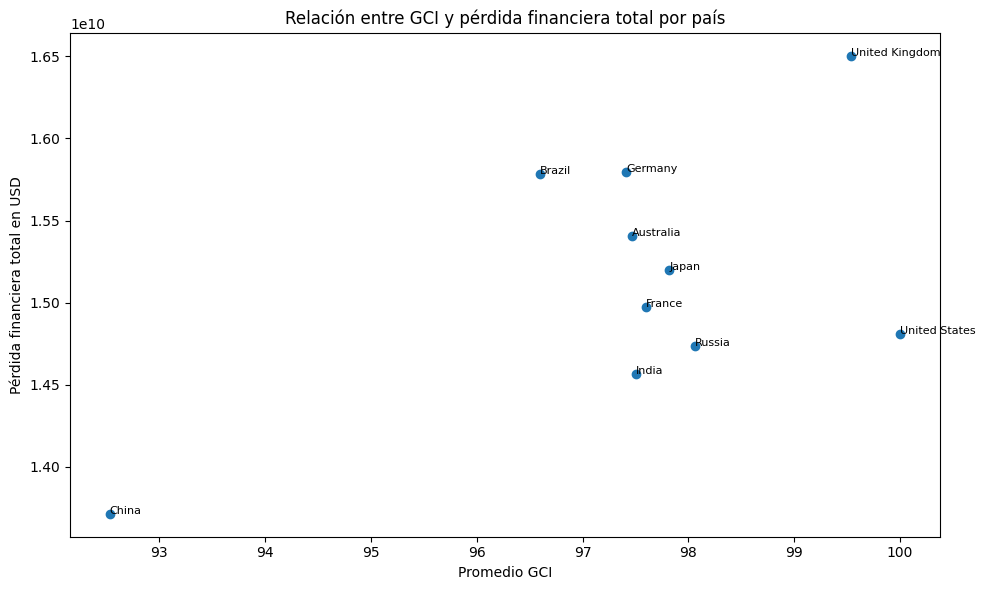

,country,promedio_gci,perdida_total_usd
8,United Kingdom,99.54,1.650299e+10
4,Germany,97.41,1.579324e+10
1,Brazil,96.60,1.578262e+10
0,Australia,97.47,1.540300e+10
6,Japan,97.82,1.519734e+10
3,France,97.60,1.497228e+10
9,United States,100.00,1.481212e+10
7,Russia,98.06,1.473473e+10
5,India,97.50,1.456612e+10
2,China,92.53,1.371447e+10


In [31]:
df_viz_gci_loss = (
    df_threats_enriched
    .groupby("country", as_index=False)
    .agg(
        promedio_gci=("gci", "mean"),
        perdida_total_usd=("financial_loss_usd", "sum")
    )
    .dropna()
)

plt.figure(figsize=(10, 6))
plt.scatter(df_viz_gci_loss["promedio_gci"], df_viz_gci_loss["perdida_total_usd"])

for _, fila in df_viz_gci_loss.iterrows():
    plt.annotate(
        fila["country"],
        (fila["promedio_gci"], fila["perdida_total_usd"]),
        fontsize=8
    )

plt.title("Relación entre GCI y pérdida financiera total por país")
plt.xlabel("Promedio GCI")
plt.ylabel("Pérdida financiera total en USD")
plt.tight_layout()
plt.show()

df_viz_gci_loss.sort_values(by="perdida_total_usd", ascending=False)

### 9.4 Conclusión de las visualizaciones

Las visualizaciones permiten observar el comportamiento de los incidentes desde tres perspectivas:

- países con mayor impacto económico,
- evolución de incidentes por año,
- relación entre indicadores de ciberseguridad y pérdidas financieras.

Estas gráficas servirán como apoyo para la interpretación del modelo estrella y para la toma de decisiones dentro de un entorno de inteligencia de negocios.


## 10. Configuración de conexión a AWS

En esta sección se prepara la configuración necesaria para conectar el notebook con los servicios de AWS.

La práctica requiere trabajar con Amazon S3 y Amazon Redshift. Para evitar escribir credenciales directamente en el código, se utilizarán variables de entorno configuradas en un archivo `.env`.

Las variables requeridas serán:

- `AWS_ACCESS_KEY_ID`
- `AWS_SECRET_ACCESS_KEY`
- `AWS_REGION`
- `S3_BUCKET_NAME`
- `S3_PREFIX`
- `REDSHIFT_HOST`
- `REDSHIFT_PORT`
- `REDSHIFT_DATABASE`
- `REDSHIFT_USER`
- `REDSHIFT_PASSWORD`
- `REDSHIFT_IAM_ROLE_ARN`

> Nota: mientras la cuenta de AWS no esté completamente verificada, esta sección puede ejecutarse dejando las variables vacías. El notebook mostrará el estado como pendiente, sin detener la ejecución.


In [ ]:
from dotenv import load_dotenv
import os

ENV_PATH = Path(".env")

if ENV_PATH.exists():
    load_dotenv(dotenv_path=ENV_PATH)
    print("Archivo .env cargado correctamente.")
else:
    print("No se encontró archivo .env. Se usarán valores pendientes de configuración.")


def obtener_variable(nombre_variable, valor_por_defecto=None):
    """
    Obtiene una variable de entorno.
    Si no existe, retorna un valor por defecto.
    """
    return os.getenv(nombre_variable, valor_por_defecto)


def enmascarar_valor(valor):
    """
    Enmascara valores sensibles para evitar mostrarlos completos en el notebook.
    """
    if valor is None or valor == "":
        return "Pendiente"
    
    valor = str(valor)
    
    if len(valor) <= 6:
        return "******"
    
    return valor[:3] + "******" + valor[-3:]


aws_config = {
    "AWS_ACCESS_KEY_ID": obtener_variable("AWS_ACCESS_KEY_ID"),
    "AWS_SECRET_ACCESS_KEY": obtener_variable("AWS_SECRET_ACCESS_KEY"),
    "AWS_REGION": obtener_variable("AWS_REGION", "us-east-1"),
    "S3_BUCKET_NAME": obtener_variable("S3_BUCKET_NAME"),
    "S3_PREFIX": obtener_variable("S3_PREFIX", "modelo_estrella"),
    "REDSHIFT_HOST": obtener_variable("REDSHIFT_HOST"),
    "REDSHIFT_PORT": obtener_variable("REDSHIFT_PORT", "5439"),
    "REDSHIFT_DATABASE": obtener_variable("REDSHIFT_DATABASE"),
    "REDSHIFT_USER": obtener_variable("REDSHIFT_USER"),
    "REDSHIFT_PASSWORD": obtener_variable("REDSHIFT_PASSWORD"),
    "REDSHIFT_IAM_ROLE_ARN": obtener_variable("REDSHIFT_IAM_ROLE_ARN")
}

configuracion_aws = pd.DataFrame([
    {
        "variable": variable,
        "valor_cargado": enmascarar_valor(valor),
        "estado": "Configurada" if valor not in [None, ""] else "Pendiente"
    }
    for variable, valor in aws_config.items()
])

configuracion_aws

## 11. Conexión a Amazon S3 y Redshift

En esta sección se preparan las conexiones a Amazon S3 y Amazon Redshift.

- **Amazon S3** se utilizará como almacenamiento intermedio para los archivos CSV del modelo estrella.
- **Amazon Redshift** será el destino final donde se cargarán las dimensiones y la tabla de hechos.

El código está preparado para no fallar si las credenciales aún no están configuradas. En ese caso, mostrará mensajes indicando que la conexión queda pendiente.


In [ ]:
try:
    import boto3
    print("boto3 importado correctamente.")
except ModuleNotFoundError:
    boto3 = None
    print("boto3 no está instalado. Ejecuta la celda de instalación de dependencias.")

try:
    import redshift_connector
    print("redshift_connector importado correctamente.")
except ModuleNotFoundError:
    redshift_connector = None
    print("redshift_connector no está instalado. Ejecuta la celda de instalación de dependencias.")

In [ ]:
def configuracion_s3_completa(config):
    """
    Verifica si existen las variables mínimas para conectar con Amazon S3.
    """
    variables_requeridas = [
        "AWS_ACCESS_KEY_ID",
        "AWS_SECRET_ACCESS_KEY",
        "AWS_REGION",
        "S3_BUCKET_NAME"
    ]
    
    return all(config.get(variable) not in [None, ""] for variable in variables_requeridas)


def configuracion_redshift_completa(config):
    """
    Verifica si existen las variables mínimas para conectar con Amazon Redshift.
    """
    variables_requeridas = [
        "REDSHIFT_HOST",
        "REDSHIFT_PORT",
        "REDSHIFT_DATABASE",
        "REDSHIFT_USER",
        "REDSHIFT_PASSWORD"
    ]
    
    return all(config.get(variable) not in [None, ""] for variable in variables_requeridas)


def crear_cliente_s3(config):
    """
    Crea un cliente de Amazon S3 usando boto3.
    Si la configuración está incompleta, retorna None.
    """
    if boto3 is None:
        print("No se puede crear cliente S3 porque boto3 no está disponible.")
        return None
    
    if not configuracion_s3_completa(config):
        print("Configuración S3 incompleta. Cliente S3 pendiente de creación.")
        return None
    
    try:
        cliente = boto3.client(
            "s3",
            region_name=config["AWS_REGION"],
            aws_access_key_id=config["AWS_ACCESS_KEY_ID"],
            aws_secret_access_key=config["AWS_SECRET_ACCESS_KEY"]
        )
        print("Cliente S3 creado correctamente.")
        return cliente
    except Exception as error:
        print("No se pudo crear el cliente S3.")
        print(error)
        return None


def crear_conexion_redshift(config):
    """
    Crea una conexión a Amazon Redshift.
    Si la configuración está incompleta, retorna None.
    """
    if redshift_connector is None:
        print("No se puede crear conexión Redshift porque redshift_connector no está disponible.")
        return None
    
    if not configuracion_redshift_completa(config):
        print("Configuración Redshift incompleta. Conexión pendiente de creación.")
        return None
    
    try:
        conexion = redshift_connector.connect(
            host=config["REDSHIFT_HOST"],
            port=int(config["REDSHIFT_PORT"]),
            database=config["REDSHIFT_DATABASE"],
            user=config["REDSHIFT_USER"],
            password=config["REDSHIFT_PASSWORD"]
        )
        print("Conexión a Redshift creada correctamente.")
        return conexion
    except Exception as error:
        print("No se pudo conectar a Redshift.")
        print(error)
        return None


s3_client = crear_cliente_s3(aws_config)
redshift_connection = crear_conexion_redshift(aws_config)

In [ ]:
estado_conexiones = pd.DataFrame([
    {
        "servicio": "Amazon S3",
        "estado": "Conectado" if s3_client is not None else "Pendiente",
        "detalle": "Cliente S3 disponible" if s3_client is not None else "Faltan credenciales o verificación de AWS"
    },
    {
        "servicio": "Amazon Redshift",
        "estado": "Conectado" if redshift_connection is not None else "Pendiente",
        "detalle": "Conexión Redshift disponible" if redshift_connection is not None else "Faltan credenciales, host o verificación de AWS"
    }
])

estado_conexiones

## 12. Función load_file para cargar dimensiones y tabla de hechos

En esta sección se crea la función `load_file`.

Esta función tiene como objetivo:

1. Tomar un archivo CSV generado en la sección 8.
2. Subirlo a un bucket de Amazon S3.
3. Preparar o ejecutar el comando `COPY` para cargarlo en Amazon Redshift.

Mientras AWS no esté completamente configurado, la función no detendrá el notebook. En su lugar, devolverá estados como `Pendiente S3` o `Pendiente Redshift`.


In [ ]:
def generar_s3_uri(bucket_name, s3_key):
    """
    Genera la ruta S3 de un archivo.
    """
    return f"s3://{bucket_name}/{s3_key}"


def generar_copy_sql(nombre_tabla, s3_uri, config):
    """
    Genera el comando COPY de Redshift para cargar un CSV desde S3.
    Usa IAM_ROLE si está configurado.
    """
    iam_role = config.get("REDSHIFT_IAM_ROLE_ARN")
    region = config.get("AWS_REGION", "us-east-1")
    
    if iam_role in [None, ""]:
        return f"""-- Pendiente: configurar REDSHIFT_IAM_ROLE_ARN
COPY {nombre_tabla}
FROM '{s3_uri}'
IAM_ROLE '<REDSHIFT_IAM_ROLE_ARN>'
FORMAT AS CSV
IGNOREHEADER 1
REGION '{region}';
"""
    
    return f"""COPY {nombre_tabla}
FROM '{s3_uri}'
IAM_ROLE '{iam_role}'
FORMAT AS CSV
IGNOREHEADER 1
REGION '{region}';
"""


def load_file(nombre_tabla, ruta_archivo, config, s3_client=None, redshift_connection=None):
    """
    Carga un archivo CSV del modelo estrella hacia S3 y prepara/ejecuta carga hacia Redshift.
    """
    ruta_archivo = Path(ruta_archivo)
    bucket_name = config.get("S3_BUCKET_NAME")
    s3_prefix = config.get("S3_PREFIX", "modelo_estrella")
    s3_key = f"{s3_prefix}/{ruta_archivo.name}"
    
    resultado = {
        "tabla": nombre_tabla,
        "archivo_local": str(ruta_archivo),
        "archivo_existe_localmente": ruta_archivo.exists(),
        "s3_key": s3_key,
        "s3_uri": generar_s3_uri(bucket_name if bucket_name else "<S3_BUCKET_NAME>", s3_key),
        "estado_s3": "Pendiente",
        "estado_redshift": "Pendiente",
        "copy_sql": ""
    }
    
    if not ruta_archivo.exists():
        resultado["estado_s3"] = "Error: archivo local no existe"
        resultado["estado_redshift"] = "No ejecutado"
        return resultado
    
    if s3_client is None or bucket_name in [None, ""]:
        resultado["estado_s3"] = "Pendiente S3: configurar cliente y bucket"
    else:
        try:
            s3_client.upload_file(str(ruta_archivo), bucket_name, s3_key)
            resultado["estado_s3"] = "Archivo cargado a S3"
        except Exception as error:
            resultado["estado_s3"] = f"Error S3: {error}"
    
    resultado["copy_sql"] = generar_copy_sql(nombre_tabla, resultado["s3_uri"], config)
    
    if redshift_connection is None:
        resultado["estado_redshift"] = "Pendiente Redshift: configurar conexión"
    elif "Archivo cargado a S3" not in resultado["estado_s3"]:
        resultado["estado_redshift"] = "No ejecutado: archivo no cargado a S3"
    else:
        try:
            cursor = redshift_connection.cursor()
            cursor.execute(resultado["copy_sql"])
            redshift_connection.commit()
            cursor.close()
            resultado["estado_redshift"] = "Carga ejecutada en Redshift"
        except Exception as error:
            resultado["estado_redshift"] = f"Error Redshift: {error}"
    
    return resultado


print("Función load_file creada correctamente.")

In [ ]:
resultados_carga = []

for _, fila in df_archivos_generados.iterrows():
    resultado = load_file(
        nombre_tabla=fila["tabla"],
        ruta_archivo=fila["archivo_csv"],
        config=aws_config,
        s3_client=s3_client,
        redshift_connection=redshift_connection
    )
    
    resultados_carga.append(resultado)

df_resultados_carga = pd.DataFrame(resultados_carga)

df_resultados_carga[[
    "tabla",
    "archivo_existe_localmente",
    "s3_uri",
    "estado_s3",
    "estado_redshift"
]]

## 13. Validación del estado de carga en Redshift

En esta sección se valida el estado de carga de la información.

La validación considera tres niveles:

1. Existencia de archivos CSV locales.
2. Estado de carga hacia Amazon S3.
3. Estado de carga hacia Amazon Redshift.

Cuando la cuenta de AWS todavía no está verificada o las credenciales no están configuradas, el estado aparecerá como pendiente.


In [ ]:
def consultar_conteo_redshift(nombre_tabla, redshift_connection):
    """
    Consulta la cantidad de registros de una tabla en Redshift.
    Si no existe conexión, retorna None.
    """
    if redshift_connection is None:
        return None
    
    try:
        cursor = redshift_connection.cursor()
        cursor.execute(f"SELECT COUNT(*) FROM {nombre_tabla};")
        total = cursor.fetchone()[0]
        cursor.close()
        return total
    except Exception as error:
        return f"Error: {error}"


validacion_estado_carga = []

for _, fila in df_resultados_carga.iterrows():
    nombre_tabla = fila["tabla"]
    conteo_redshift = consultar_conteo_redshift(nombre_tabla, redshift_connection)
    
    validacion_estado_carga.append({
        "tabla": nombre_tabla,
        "archivo_local": "OK" if fila["archivo_existe_localmente"] else "No existe",
        "estado_s3": fila["estado_s3"],
        "estado_redshift": fila["estado_redshift"],
        "registros_redshift": conteo_redshift if conteo_redshift is not None else "Pendiente"
    })

df_validacion_estado_carga = pd.DataFrame(validacion_estado_carga)

df_validacion_estado_carga

In [ ]:
resumen_estado_carga = pd.DataFrame([
    {
        "validacion": "Archivos CSV locales generados",
        "resultado": df_resultados_carga["archivo_existe_localmente"].all(),
        "detalle": f"{int(df_resultados_carga['archivo_existe_localmente'].sum())} de {len(df_resultados_carga)} archivos existen localmente"
    },
    {
        "validacion": "Carga a S3 completada",
        "resultado": (df_resultados_carga["estado_s3"] == "Archivo cargado a S3").all(),
        "detalle": "Pendiente si AWS aún no está configurado"
    },
    {
        "validacion": "Carga a Redshift completada",
        "resultado": (df_resultados_carga["estado_redshift"] == "Carga ejecutada en Redshift").all(),
        "detalle": "Pendiente si Redshift aún no está configurado"
    }
])

resumen_estado_carga

## 14. Reflexión individual final

### Solis Paulo

Este proceso de carga final hacia un entorno en la nube representa una etapa muy importante dentro de un proyecto ETL, porque permite pasar de tener datos limpios y transformados en archivos locales a disponer de una estructura analítica centralizada, consultable y preparada para la toma de decisiones. En un contexto profesional relacionado con tecnología, datos o ciberseguridad, este tipo de flujo sería muy útil para consolidar información que normalmente se encuentra dispersa en distintas fuentes, como registros de eventos, reportes de incidentes, métricas de usuarios, indicadores de seguridad o información operativa.

Aplicaría este proceso utilizando Amazon S3 como repositorio intermedio para almacenar archivos validados y Amazon Redshift como destino final para consultar dimensiones y tablas de hechos. Esto permitiría construir reportes o dashboards sobre indicadores clave, por ejemplo, incidentes por país, pérdidas financieras, tipos de ataque más frecuentes o tiempos de resolución. Además, documentar cada paso en un notebook facilita la trazabilidad del proceso, ya que permite evidenciar cómo se prepararon los datos, cómo se generaron los archivos finales y cómo fueron cargados al destino analítico.

En un entorno laboral, esta práctica aportaría valor porque ayudaría a automatizar cargas periódicas, reducir errores manuales y disponer de información confiable para análisis estratégicos. También permitiría que diferentes áreas trabajen con una única fuente de datos organizada, mejorando la calidad de las decisiones y la capacidad de respuesta ante problemas reales.
